# Importing Library

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.layers import Input, BatchNormalization, Dropout, Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.metrics import BinaryAccuracy, Precision, Recall, AUC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import math
import json

# Importing Dataset

In [ ]:
IM_SIZE = 128
BATCH_SIZE = 16

import tensorflow_datasets as tfds
full_ds, ds_info = tfds.load(
    "malaria",
    split="train",
    as_supervised=True,
    shuffle_files=True,
    with_info=True
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/malaria/incomplete.W6SVP9_1.0.0/malaria-train.tfrecord*...:   0%|         …

Dataset malaria downloaded and prepared to /root/tensorflow_datasets/malaria/1.0.0. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='malaria',
    full_name='malaria/1.0.0',
    description="""
    The Malaria dataset contains a total of 27,558 cell images with equal instances
    of parasitized and uninfected cells from the thin blood smear slide images of
    segmented cells.
    """,
    homepage='https://lhncbc.nlm.nih.gov/publication/pub9932',
    data_dir='/root/tensorflow_datasets/malaria/1.0.0',
    file_format=tfrecord,
    download_size=337.08 MiB,
    dataset_size=317.62 MiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=27558, num_shards=4>,
    },
    citation="""@article{rajaraman

# Data Preprocessing

## Resizing the Image

In [ ]:
def resize_and_normalize(image, label):
    image = tf.image.resize(image, [IM_SIZE, IM_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.per_image_standardization(image)
    return image, label

full_ds = full_ds.map(resize_and_normalize).prefetch(tf.data.AUTOTUNE)

## Splitting the Image into 70% Train , 15% Val and 15% Test Set

In [ ]:
total_batches = tf.data.experimental.cardinality(full_ds).numpy()
train_size = int(0.7 * total_batches)
val_size = int(0.15 * total_batches)
test_size = total_batches - train_size - val_size

train_ds = full_ds.take(train_size)
remaining_ds = full_ds.skip(train_size)
val_ds = remaining_ds.take(val_size)
test_ds = remaining_ds.skip(val_size)

print(f"Train size: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Val size: {tf.data.experimental.cardinality(val_ds).numpy()}")
print(f"Test size: {tf.data.experimental.cardinality(test_ds).numpy()}")

Train size: 19290
Val size: 4133
Test size: 4135


## Data Augmentation

In [ ]:
def augment(image, label):
    if tf.random.uniform([]) < 0.7:
        image = tf.image.rot90(image, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
    if tf.random.uniform([]) < 0.6:
        image = tf.image.random_flip_left_right(image)
    if tf.random.uniform([]) < 0.6:
        image = tf.image.random_flip_up_down(image)
    if tf.random.uniform([]) < 0.5:
        image = tf.image.random_brightness(image, 0.02)
    if tf.random.uniform([]) < 0.5:
        image = tf.image.random_contrast(image, 0.95, 1.05)
    if tf.random.uniform([]) < 0.3:
        noise = tf.random.normal(tf.shape(image), mean=0.0, stddev=0.015)
        image = image + noise
    if tf.random.uniform([]) < 0.3:
        zoom_factor = tf.random.uniform([], 0.95, 1.05)
        h, w = tf.shape(image)[0], tf.shape(image)[1]
        new_h = tf.cast(tf.cast(h, tf.float32) * zoom_factor, tf.int32)
        new_w = tf.cast(tf.cast(w, tf.float32) * zoom_factor, tf.int32)
        image = tf.image.resize(image, [new_h, new_w])
        image = tf.image.resize_with_crop_or_pad(image, h, w)

    image = tf.clip_by_value(image, -2, 2)
    return image, label

train_ds = train_ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Data Visualization

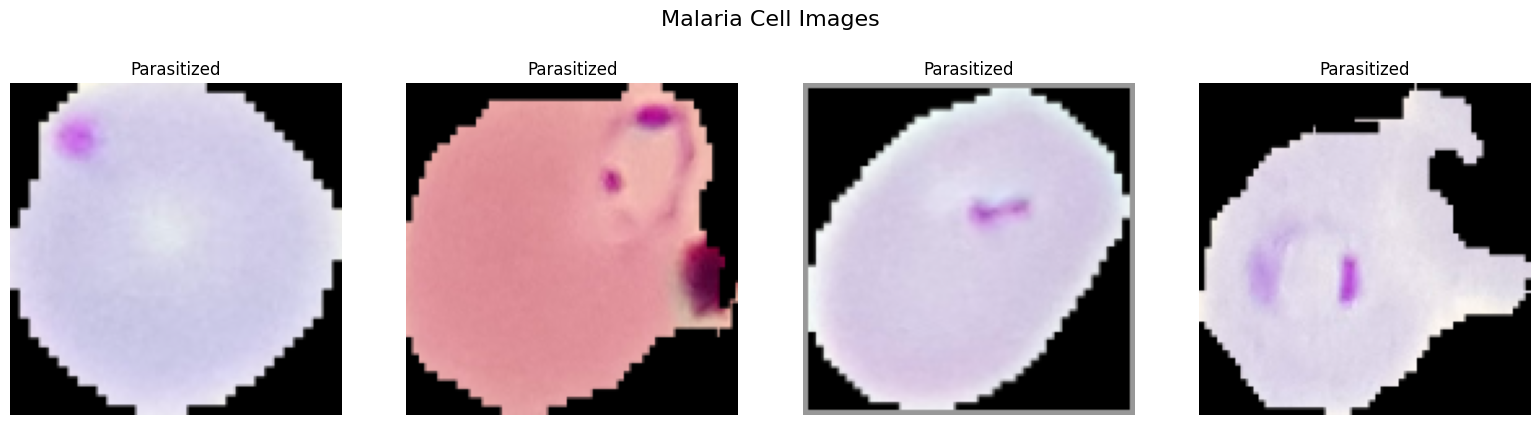

In [ ]:
def show_augmented_samples(dataset, num_samples=4):
    import matplotlib.pyplot as plt

    class_names = ['Parasitized', 'Uninfected']
    plt.figure(figsize=(16, 4))

    for images, labels in dataset.take(1):
        for i in range(min(num_samples, len(images))):
            img = images[i].numpy()
            if img.min() < 0 or img.max() > 1:
                img = (img - img.min()) / (img.max() - img.min())

            plt.subplot(1, num_samples, i + 1)
            plt.imshow(img)
            plt.title(class_names[labels[i].numpy()])
            plt.axis('off')

    plt.suptitle('Malaria Cell Images', fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()

show_augmented_samples(train_ds, num_samples=4)

# Model Creation

In [ ]:
def build_model(input_shape=(IM_SIZE, IM_SIZE, 3)):

        inputs = Input(shape=input_shape)

        base_model = tf.keras.applications.ResNet50(
            input_tensor=inputs,
            include_top=False,
            weights='imagenet'
        )

        base_model.trainable = False

        x = base_model.output
        x = GlobalAveragePooling2D()(x)
        x = Dropout(0.4)(x)

        x = Dense(128, activation='relu')(x)
        x = BatchNormalization()(x)
        x = Dropout(0.3)(x)
        outputs = Dense(1, activation='sigmoid')(x)
        model = Model(inputs, outputs)
        return model, base_model

model, base_model = build_model(input_shape=(IM_SIZE, IM_SIZE, 3))
model.summary()

INITIAL_EPOCHS = 5
FINE_TUNE_EPOCHS = 20


def cosine_decay_with_warmup(epoch, max_epochs, warmup_epochs=3):

    if epoch < warmup_epochs:
        return 0.0001 * (epoch + 1) / warmup_epochs
    else:

        decay_epochs = max(max_epochs - warmup_epochs, 1)
        return 0.001 * 0.5 * (1 + math.cos(math.pi * (epoch - warmup_epochs) / decay_epochs))

def lr_scheduler(epoch):
    return cosine_decay_with_warmup(epoch, INITIAL_EPOCHS, warmup_epochs=3)

optimizer = tf.keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.01)
model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=[BinaryAccuracy(name='accuracy'), Precision(name='precision'),
             Recall(name='recall'), AUC(name='auc')]
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,625 (90.98 MB)

 Trainable params: 262,657 (1.00 MB)

 Non-trainable params: 23,587,968 (89.98 MB)

# Training The Model

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_auc', patience=15, restore_best_weights=True, verbose=1, mode='max'),
    ReduceLROnPlateau(monitor='val_auc', factor=0.3, patience=8, min_lr=1e-8, verbose=1, mode='max'),
    ModelCheckpoint(filepath='best_malaria_model.keras', monitor='val_auc', save_best_only=True, mode='max', verbose=1),
    tf.keras.callbacks.LearningRateScheduler(lr_scheduler, verbose=1)
]

print("Starting initial training...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Starting initial training...

Epoch 1: LearningRateScheduler setting learning rate to 3.3333333333333335e-05.
Epoch 1/5
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5502 - auc: 0.5707 - loss: 0.8265 - precision: 0.5540 - recall: 0.5552
Epoch 1: val_auc improved from -inf to 0.72253, saving model to best_malaria_model.keras
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 88s 52ms/step - accuracy: 0.5502 - auc: 0.5708 - loss: 0.8265 - precision: 0.5540 - recall: 0.5552 - val_accuracy: 0.6632 - val_auc: 0.7225 - val_loss: 0.6190 - val_precision: 0.6616 - val_recall: 0.6686 - learning_rate: 3.3333e-05

Epoch 2: LearningRateScheduler setting learning rate to 6.666666666666667e-05.
Epoch 2/5
1204/1206 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6030 - auc: 0.6439 - loss: 0.7100 - precision: 0.6118 - recall: 0.5811
Epoch 2: val_auc improved from 0.72253 to 0.76187, saving model to best_malaria_model.keras
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 59s 41ms/step - accuracy: 0.6030 - auc: 0.6439 - loss: 0.

# Fine-Tuning

In [ ]:
print("Starting fine-tuning...")
base_model.trainable = True
fine_tune_lr = 1e-5

def fine_tune_lr_scheduler(epoch):

    return fine_tune_lr * (0.9 ** epoch)

fine_tune_callbacks = [
    EarlyStopping(monitor='val_auc', patience=3, restore_best_weights=True, verbose=1, mode='max'),
    ReduceLROnPlateau(monitor='val_auc', factor=0.3, patience=8, min_lr=1e-8, verbose=1, mode='max'),
    ModelCheckpoint(filepath='best_malaria_model.keras', monitor='val_auc', save_best_only=True, mode='max', verbose=1),
    tf.keras.callbacks.LearningRateScheduler(fine_tune_lr_scheduler, verbose=1)
]

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=fine_tune_lr),
    loss='binary_crossentropy',
    metrics=[BinaryAccuracy(name='accuracy'), Precision(name='precision'),
             Recall(name='recall'), AUC(name='auc')]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS + FINE_TUNE_EPOCHS,
    initial_epoch=len(history.history['loss']),
    callbacks=fine_tune_callbacks,
    verbose=1
)

Starting fine-tuning...

Epoch 6: LearningRateScheduler setting learning rate to 5.904900000000001e-06.
Epoch 6/25
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.7960 - auc: 0.8674 - loss: 0.4635 - precision: 0.8059 - recall: 0.7836
Epoch 6: val_auc improved from -inf to 0.98590, saving model to best_malaria_model.keras
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 233s 145ms/step - accuracy: 0.7960 - auc: 0.8674 - loss: 0.4633 - precision: 0.8059 - recall: 0.7837 - val_accuracy: 0.9521 - val_auc: 0.9859 - val_loss: 0.1516 - val_precision: 0.9461 - val_recall: 0.9589 - learning_rate: 5.9049e-06

Epoch 7: LearningRateScheduler setting learning rate to 5.314410000000001e-06.
Epoch 7/25
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9385 - auc: 0.9802 - loss: 0.1778 - precision: 0.9357 - recall: 0.9427
Epoch 7: val_auc improved from 0.98590 to 0.99072, saving model to best_malaria_model.keras
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 131s 108ms/step - accuracy: 0.9385 - auc: 0.9802 - loss: 0

# Model Evaluation and Testing

In [ ]:
def combine_histories(hist1, hist2):
    combined = {}
    for key in hist1.history.keys():
        combined[key] = hist1.history[key] + hist2.history[key]
    return type('History', (), {'history': combined})()

combined_history = combine_histories(history, history_fine)

print("Evaluating on test set...")
test_results = model.evaluate(test_ds, verbose=1)
print(f"Test Loss: {test_results[0]:.4f}")
print(f"Test Accuracy: {test_results[1]:.4f}")
print(f"Test Precision: {test_results[2]:.4f}")
print(f"Test Recall: {test_results[3]:.4f}")
print(f"Test AUC: {test_results[4]:.4f}")

Evaluating on test set...
259/259 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.9683 - auc: 0.9936 - loss: 0.0963 - precision: 0.9648 - recall: 0.9734
Test Loss: 0.1015
Test Accuracy: 0.9654
Test Precision: 0.9630
Test Recall: 0.9681
Test AUC: 0.9930


# Visualize The Model Accuracy

Optimal threshold 0.561 saved to 'threshold.json'


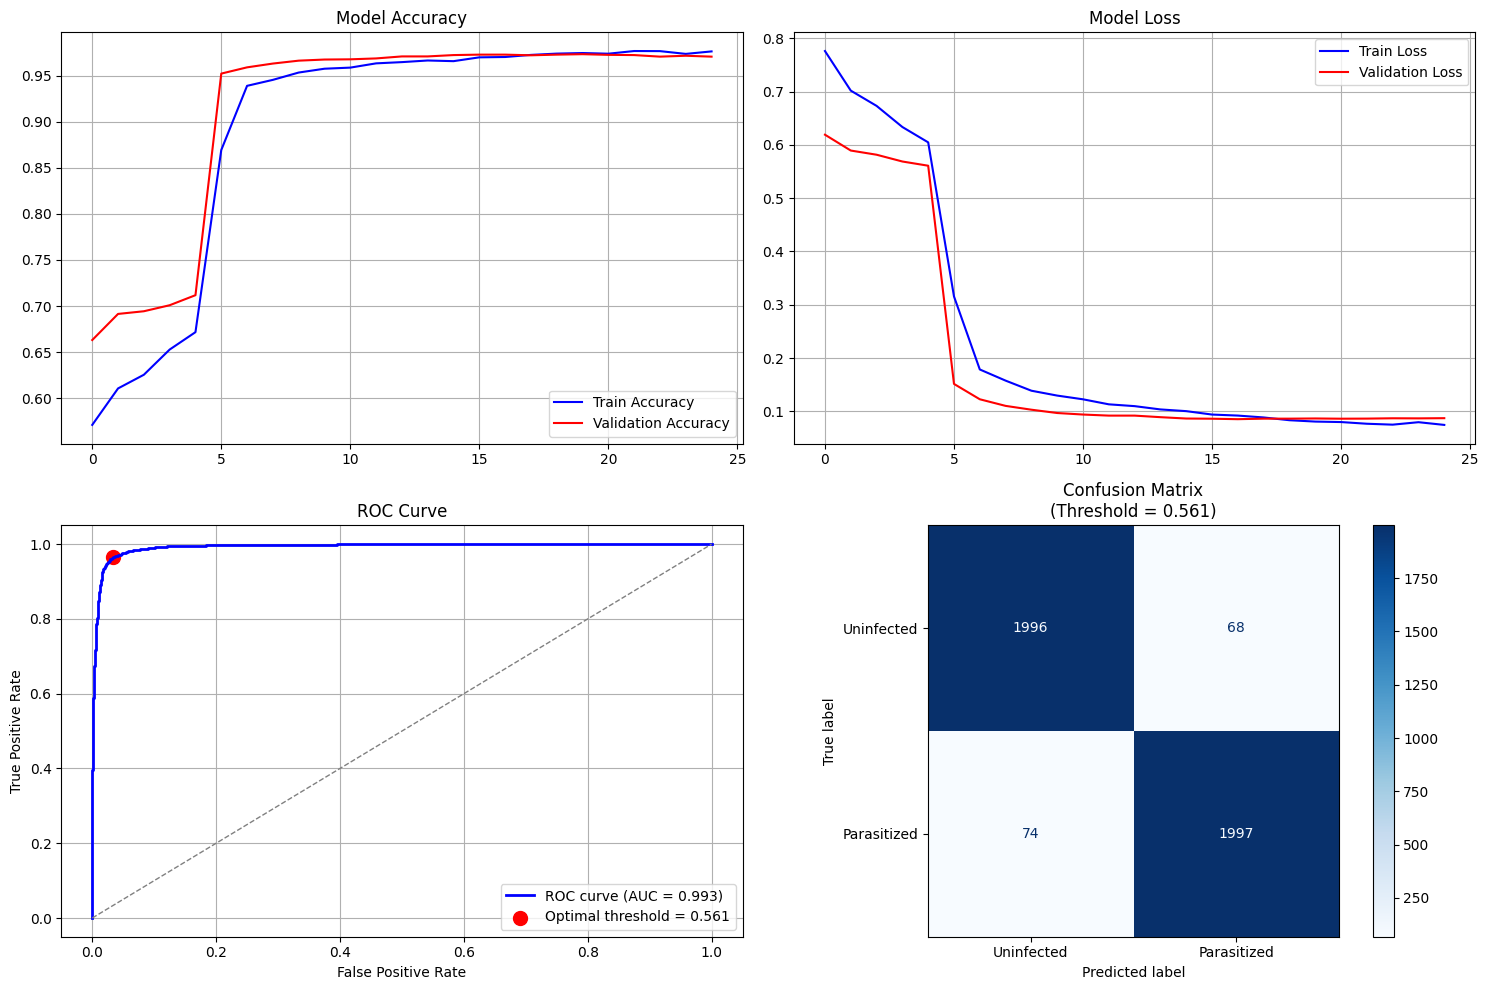

In [ ]:
def plot_training_and_evaluation(history, model, test_ds, threshold_file="threshold.json"):
    y_true = []
    y_pred_prob = []

    for images, labels in test_ds:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy().flatten())
        y_pred_prob.extend(preds.flatten())

    y_true = np.array(y_true)
    y_pred_prob = np.array(y_pred_prob)

    fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]
    y_pred = (y_pred_prob > optimal_threshold).astype(int)

    with open(threshold_file, "w") as f:
        json.dump({"optimal_threshold": float(optimal_threshold)}, f)
    print(f"Optimal threshold {optimal_threshold:.3f} saved to '{threshold_file}'")

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Top-left: Accuracy
    axes[0, 0].plot(history.history['accuracy'], label='Train Accuracy', color='blue')
    axes[0, 0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
    axes[0, 0].set_title('Model Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    # Top-right: Loss
    axes[0, 1].plot(history.history['loss'], label='Train Loss', color='blue')
    axes[0, 1].plot(history.history['val_loss'], label='Validation Loss', color='red')
    axes[0, 1].set_title('Model Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    # Bottom-left: ROC Curve
    axes[1, 0].plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    axes[1, 0].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
    axes[1, 0].scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', s=100,
                       label=f'Optimal threshold = {optimal_threshold:.3f}')
    axes[1, 0].set_xlabel('False Positive Rate')
    axes[1, 0].set_ylabel('True Positive Rate')
    axes[1, 0].set_title('ROC Curve')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    # Bottom-right: Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Uninfected', 'Parasitized'])
    disp.plot(ax=axes[1, 1], cmap='Blues')
    axes[1, 1].set_title(f'Confusion Matrix\n(Threshold = {optimal_threshold:.3f})')

    plt.tight_layout()
    plt.show()

    return optimal_threshold, roc_auc

optimal_threshold, roc_auc = plot_training_and_evaluation(combined_history, model, test_ds)



[TP FP
  FN TN
]

# Actual vs Predicted Visualization

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


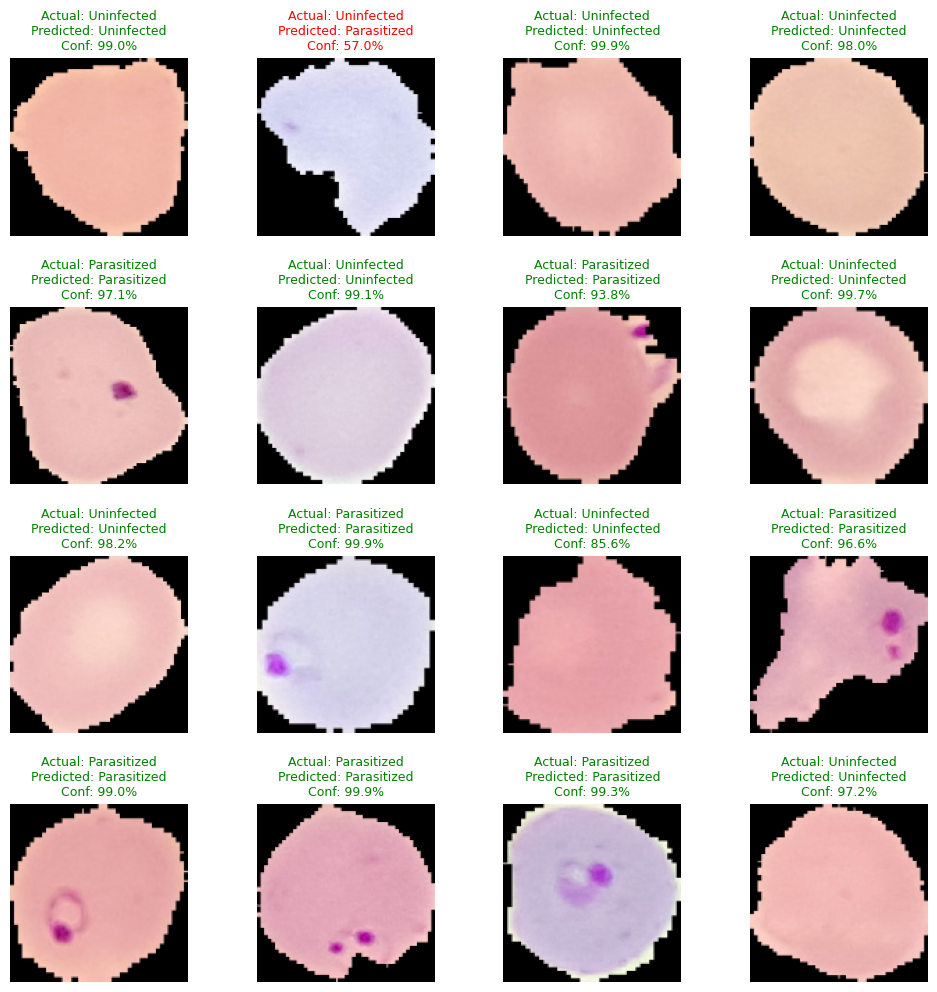

In [ ]:
def plot_actual_vs_predicted_full(model, dataset, class_names=['Parasitized', 'Uninfected'], num_samples=16, threshold=0.5):
    import matplotlib.pyplot as plt
    import numpy as np

    rows = cols = int(np.sqrt(num_samples))

    fig, axes = plt.subplots(rows, cols, figsize=(12, 12))
    axes = axes.flatten()

    for images, labels in dataset.take(1):
        preds = model.predict(images)
        pred_labels = (preds > threshold).astype(int).flatten()

        for i in range(min(num_samples, len(images))):
            img = images[i].numpy()
            if img.min() < 0 or img.max() > 1:
                img = (img - img.min()) / (img.max() - img.min())

            axes[i].imshow(img)
            true_label = class_names[labels[i].numpy()]
            predicted_label = class_names[pred_labels[i]]
            confidence = preds[i][0] if pred_labels[i] == 1 else 1 - preds[i][0]

            color = 'green' if labels[i].numpy() == pred_labels[i] else 'red'

            axes[i].set_title(f"Actual: {true_label}\nPredicted: {predicted_label}\nConf: {confidence*100:.1f}%",
                              fontsize=9, color=color)
            axes[i].axis('off')
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    fig.subplots_adjust(wspace=0.3, hspace=0.4)
    plt.show()

plot_actual_vs_predicted_full(model, test_ds, num_samples=16, threshold=optimal_threshold)
